In [2]:
pip install gwaslab 


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import gwaslab as gl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import pandas as pd
import gzip

file_path = "../data/21001_raw.gwas.imputed_v3.both_sexes.tsv.bgz"
with gzip.open(file_path, 'rt') as f:
    df = pd.read_csv(f, sep='\t') 


In [5]:
df.head()


,variant,minor_allele,minor_AF,low_confidence_variant,n_complete_samples,AC,ytx,beta,se,tstat,pval
0,1:15791:C:T,T,5.446880e-09,True,359983,0.003922,1.238950e-01,894.616000,1204.870000,0.742499,0.457786
1,1:69487:G:A,A,5.768250e-06,True,359983,4.152940,1.035150e+02,-2.715450,2.360060,-1.150590,0.249902
2,1:69569:T:C,C,1.878960e-04,True,359983,135.278000,3.644560e+03,-0.484284,0.423462,-1.143630,0.252778
3,1:139853:C:T,T,5.681100e-06,True,359983,4.090200,1.018400e+02,-2.703560,2.360130,-1.145510,0.251997
4,1:692794:CA:C,C,1.105900e-01,False,359983,79621.100000,2.179000e+06,-0.016436,0.019585,-0.839228,0.401342


In [6]:
df['CHR'] = df['variant'].str.split(':').str[0]
df['POS'] = df['variant'].str.split(':').str[1]
df['A2']=df['variant'].str.split(':').str[2]
df['A1']=df['variant'].str.split(':').str[3]



In [7]:
df.shape

(13791467, 15)

In [8]:
df=df.rename(columns={'variant':'SNPID', 'pval':'P'})
df.head()


,SNPID,minor_allele,minor_AF,low_confidence_variant,n_complete_samples,AC,ytx,beta,se,tstat,P,CHR,POS,A2,A1
0,1:15791:C:T,T,5.446880e-09,True,359983,0.003922,1.238950e-01,894.616000,1204.870000,0.742499,0.457786,1,15791,C,T
1,1:69487:G:A,A,5.768250e-06,True,359983,4.152940,1.035150e+02,-2.715450,2.360060,-1.150590,0.249902,1,69487,G,A
2,1:69569:T:C,C,1.878960e-04,True,359983,135.278000,3.644560e+03,-0.484284,0.423462,-1.143630,0.252778,1,69569,T,C
3,1:139853:C:T,T,5.681100e-06,True,359983,4.090200,1.018400e+02,-2.703560,2.360130,-1.145510,0.251997,1,139853,C,T
4,1:692794:CA:C,C,1.105900e-01,False,359983,79621.100000,2.179000e+06,-0.016436,0.019585,-0.839228,0.401342,1,692794,CA,C


In [9]:
df.head()

,SNPID,minor_allele,minor_AF,low_confidence_variant,n_complete_samples,AC,ytx,beta,se,tstat,P,CHR,POS,A2,A1
0,1:15791:C:T,T,5.446880e-09,True,359983,0.003922,1.238950e-01,894.616000,1204.870000,0.742499,0.457786,1,15791,C,T
1,1:69487:G:A,A,5.768250e-06,True,359983,4.152940,1.035150e+02,-2.715450,2.360060,-1.150590,0.249902,1,69487,G,A
2,1:69569:T:C,C,1.878960e-04,True,359983,135.278000,3.644560e+03,-0.484284,0.423462,-1.143630,0.252778,1,69569,T,C
3,1:139853:C:T,T,5.681100e-06,True,359983,4.090200,1.018400e+02,-2.703560,2.360130,-1.145510,0.251997,1,139853,C,T
4,1:692794:CA:C,C,1.105900e-01,False,359983,79621.100000,2.179000e+06,-0.016436,0.019585,-0.839228,0.401342,1,692794,CA,C


In [35]:

minor_df=df[df['minor_AF'] > 0.05]
minor_df = minor_df[~minor_df['SNPID'].str.startswith('X:')]
minor_df.head()


,SNPID,minor_allele,minor_AF,low_confidence_variant,n_complete_samples,AC,ytx,beta,se,tstat,P,CHR,POS,A2,A1
4,1:692794:CA:C,C,0.110590,False,359983,79621.1,2179000.0,-0.016436,0.019585,-0.839228,0.401342,1,692794,CA,C
5,1:693731:A:G,G,0.115767,False,359983,83348.0,2281760.0,-0.004255,0.018507,-0.229918,0.818155,1,693731,A,G
6,1:707522:G:C,C,0.097255,False,359983,70020.6,1916410.0,-0.010428,0.020804,-0.501258,0.616190,1,707522,G,C
9,1:730087:T:C,C,0.056424,False,359983,40623.1,1110650.0,-0.047388,0.025783,-1.837930,0.066074,1,730087,T,C
10,1:731718:T:C,C,0.121670,False,359983,87598.4,2397990.0,-0.005842,0.017552,-0.332853,0.739246,1,731718,T,C


In [22]:
import gwaslab as gl
sumstats=gl.Sumstats(minor_df, snpid='SNPID', pos="POS" , a1="A1", a2="A2", beta="beta", se="se", eaf="minor_AF" ,fmt='plink')
sumstats.data.shape

2025/02/10 22:46:01 GWASLab v3.5.5 https://cloufield.github.io/gwaslab/
2025/02/10 22:46:01 (C) 2022-2025, Yunye He, Kamatani Lab, GPL-3.0 license, gwaslab@gmail.com
2025/02/10 22:46:01 Start to load format from formatbook....
2025/02/10 22:46:01  -plink format meta info:
2025/02/10 22:46:01   - format_name  : .assoc, .assoc.fisher, .assoc.linear, .assoc.logistic, .assoc.dosage
2025/02/10 22:46:01   - format_source  : https://www.cog-genomics.org/plink/1.9/
2025/02/10 22:46:01   - format_version  : Stable (beta 6.26, 2 Apr)
2025/02/10 22:46:01   - format_citation  : Purcell, S., Neale, B., Todd-Brown, K., Thomas, L., Ferreira, M. A., Bender, D., ... & Sham, P. C. (2007). PLINK: a tool set for whole-genome association and population-based linkage analyses. The American journal of human genetics, 81(3), 559-575.
2025/02/10 22:46:01  -plink to gwaslab format dictionary:
2025/02/10 22:46:01   - plink keys: SNP,CHR,BP,A2,A1,BETA,OR,SE,P,INFO,STAT,CHISQ,NMISS
2025/02/10 22:46:01   - gwaslab 

(6746855, 10)

In [23]:
sumstats.data

,SNPID,CHR,POS,EA,NEA,EAF,BETA,SE,P,STATUS
4,1:692794:CA:C,1,692794,C,CA,0.110590,-0.016436,0.019585,0.401342,9999999
5,1:693731:A:G,1,693731,G,A,0.115767,-0.004255,0.018507,0.818155,9999999
6,1:707522:G:C,1,707522,C,G,0.097255,-0.010428,0.020804,0.616190,9999999
9,1:730087:T:C,1,730087,C,T,0.056424,-0.047388,0.025783,0.066074,9999999
10,1:731718:T:C,1,731718,C,T,0.121670,-0.005842,0.017552,0.739246,9999999
...,...,...,...,...,...,...,...,...,...,...
13364298,22:51229717:A:T,22,51229717,T,A,0.296108,0.017674,0.013538,0.191730,9999999
13364299,22:51229805:T:C,22,51229805,C,T,0.072990,0.002137,0.021510,0.920869,9999999
13364300,22:51231220:A:G,22,51231220,G,A,0.053686,0.008422,0.026450,0.750181,9999999
13364301,22:51237063:T:C,22,51237063,C,T,0.299001,0.021242,0.013134,0.105807,9999999


In [29]:

print(dir(sumstats))


['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slotnames__', '__str__', '__subclasshook__', '__weakref__', 'abf_finemapping', 'anno_gene', 'assign_rsid', 'basic_check', 'build', 'calculate_ld_matrix', 'calculate_prs', 'check_af', 'check_cis', 'check_data_consistency', 'check_id', 'check_novel_set', 'check_ref', 'check_sanity', 'clump', 'clumps', 'data', 'estimate_h2_by_ldsc', 'estimate_h2_cts_by_ldsc', 'estimate_partitioned_h2_by_ldsc', 'estimate_rg_by_ldsc', 'exclude_hla', 'fill_data', 'filter_flanking', 'filter_flanking_by_chrpos', 'filter_flanking_by_id', 'filter_hapmap3', 'filter_in', 'filter_indel', 'filter_out', 'filter_palindromic', 'filter_region_in', 'filter_region_out', 'filter_snp', 'filter_value', 'finemapping', 'fix_allele

In [27]:
sumstats.get_lead(sig_level=5e-8)

2025/02/10 22:55:15 Start to extract lead variants...v3.5.5
2025/02/10 22:55:15  -Current Dataframe shape : 6746855 x 10 ; Memory usage: 506.00 MB
2025/02/10 22:55:15  -Processing 6746855 variants...
2025/02/10 22:55:15  -Significance threshold : 5e-08
2025/02/10 22:55:15  -Sliding window size: 500  kb
2025/02/10 22:55:17  -Using P for extracting lead variants...
2025/02/10 22:55:17  -Found 49937 significant variants in total...
2025/02/10 22:55:19  -Identified 440 lead variants!
2025/02/10 22:55:19 Finished extracting lead variants.


,SNPID,CHR,POS,EA,NEA,EAF,BETA,SE,P,STATUS
4481,1:1590521:G:A,1,1590521,A,G,0.265231,-0.100267,0.012675,2.570000e-15,9999999
10167,1:2723214:C:A,1,2723214,A,C,0.465833,-0.074539,0.011238,3.299290e-11,9999999
33413,1:6669970:C:G,1,6669970,G,C,0.355676,0.064158,0.011662,3.770110e-08,9999999
94800,1:19964098:C:T,1,19964098,T,C,0.237297,-0.071745,0.013152,4.894670e-08,9999999
112330,1:23422623:GA:G,1,23422623,G,GA,0.186877,-0.095363,0.015819,1.658770e-09,9999999
...,...,...,...,...,...,...,...,...,...,...
13150460,21:42653237:A:G,21,42653237,G,A,0.354242,0.064322,0.011670,3.556230e-08,9999999
13158951,21:43966144:A:G,21,43966144,G,A,0.383044,-0.063586,0.011475,3.000680e-08,9999999
13174548,21:46488959:G:A,21,46488959,A,G,0.054446,-0.188362,0.024674,2.279990e-14,9999999
13301879,22:40677499:A:AT,22,40677499,AT,A,0.324047,-0.091490,0.012044,3.056980e-14,9999999


In [13]:
# sumstats.plot_mqq(skip=2,anno=True)

In [14]:
# sumstats.plot_mqq(mode="r", anno=True, region=(1, 110232801, 151018861), region_grid=True, build='hg19')



In [25]:
variant_position = 53767042
start_pos= variant_position- 100000
end_pos= variant_position +100000

In [14]:
locus = sumstats.filter_value(f'CHR==16 & POS>{start_pos} & POS<{end_pos}')
print(locus.data.shape)

2025/02/10 22:38:45 Start filtering values by condition: CHR==16 & POS>53667042 & POS<53867042
2025/02/10 22:38:45  -Removing 6746422 variants not meeting the conditions: CHR==16 & POS>53667042 & POS<53867042
2025/02/10 22:38:45 Finished filtering values.
(433, 10)


In [164]:

locus.fill_data(to_fill=["BETA"])
df = locus.data.copy()
df.shape


2025/02/10 06:22:49 Start filling data using existing columns...v3.5.5
2025/02/10 06:22:49  -Column  : SNPID  CHR   POS   EA       NEA      EAF     BETA    SE      P       STATUS  
2025/02/10 06:22:49  -DType   : object Int64 int64 category category float64 float64 float64 float64 category
2025/02/10 06:22:49  -Verified: T      T     T     T        T        T       T       T       T       T       
2025/02/10 06:22:49  -Overwrite mode:  False
2025/02/10 06:22:49   -Skipping columns:  ['BETA']
2025/02/10 06:22:49  -No available columns to fill. Skipping.
2025/02/10 06:22:49 Finished filling data using existing columns.
2025/02/10 06:22:49 Start to reorder the columns...v3.5.5
2025/02/10 06:22:49  -Current Dataframe shape : 433 x 10 ; Memory usage: 23.45 MB
2025/02/10 06:22:49  -Reordering columns to    : SNPID,CHR,POS,EA,NEA,EAF,BETA,SE,P,STATUS
2025/02/10 06:22:49 Finished reordering the columns.


(433, 10)

In [41]:
df_locus_zoom=df[["SNPID", "CHR", "POS","P"]]
df_locus_zoom.head()
df_locus_zoom['BP']=df['POS']
df_locus_zoom=df[["SNPID", "CHR", "POS","P"]]
df_locus_zoom.to_csv("../notebooksdf_locus_zoom.csv")



/tmp/ipykernel_2946517/2615186401.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_locus_zoom['BP']=df['POS']


In [165]:
df["SNPID"].to_csv("../data/snplist/sig_locus.snplist.txt",sep="\t",index=None,header=None)


In [188]:
df["SNPID"].head()
df["SNPID"].to_csv("../data/snplist/plot_sig_locs.snplist.txt",sep="\t",index=None,header=None)

df["SNPID"].shape


(433,)

In [190]:
df = df.head(429)
df.shape

(429, 10)

In [185]:
!plink \
  --bfile "../data/plot_chr16_eur/chr16_eur" \
  --keep-allele-order \
  --r square \
  --extract ../data/snplist/plot_sig_locs.snplist.txt \
  --out ../data/plot_ld/plot_sig_locus_mt

!plink \
  --bfile "../data/plot_chr16_eur/chr16_eur" \
  --keep-allele-order \
  --r2 square \
  --extract ../data/snplist/plot_sig_locs.snplist.txt \
  --out ../data/plot_ld/plot_sig_locus_mt_r2

PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ../data/plot_ld/plot_sig_locus_mt.log.
Options in effect:
  --bfile ../data/plot_chr16_eur/chr16_eur
  --extract ../data/snplist/plot_sig_locs.snplist.txt
  --keep-allele-order
  --out ../data/plot_ld/plot_sig_locus_mt
  --r square

257418 MB RAM detected; reserving 128709 MB for main workspace.
2697949 variants loaded from .bim file.
503 people (0 males, 0 females, 503 ambiguous) loaded from .fam.
Ambiguous sex IDs written to ../data/plot_ld/plot_sig_locus_mt.nosex .
--extract: 429 variants remaining.
Using up to 27 threads (change this with --threads).
Before main variant filters, 503 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929

In [191]:

from rpy2.robjects.packages import importr
import rpy2.robjects as ro
import rpy2.robjects.numpy2ri as numpy2ri
import rpy2.robjects.pandas2ri as pandas2ri
numpy2ri.activate()
pandas2ri.activate()

In [192]:
#Load LD data
ld = pd.read_csv("../data/plot_ld/plot_sig_locus_mt.ld", sep="\t", header=None)
R_df = ld.values
ld2 = pd.read_csv("../data/plot_ld/plot_sig_locus_mt_r2.ld",sep="\t",header=None)
R_df2 = ld2.values
R_df.shape

(429, 429)

Text(0.5, 1.0, 'LD r2 matrix')

<Figure size 2000x2000 with 0 Axes>

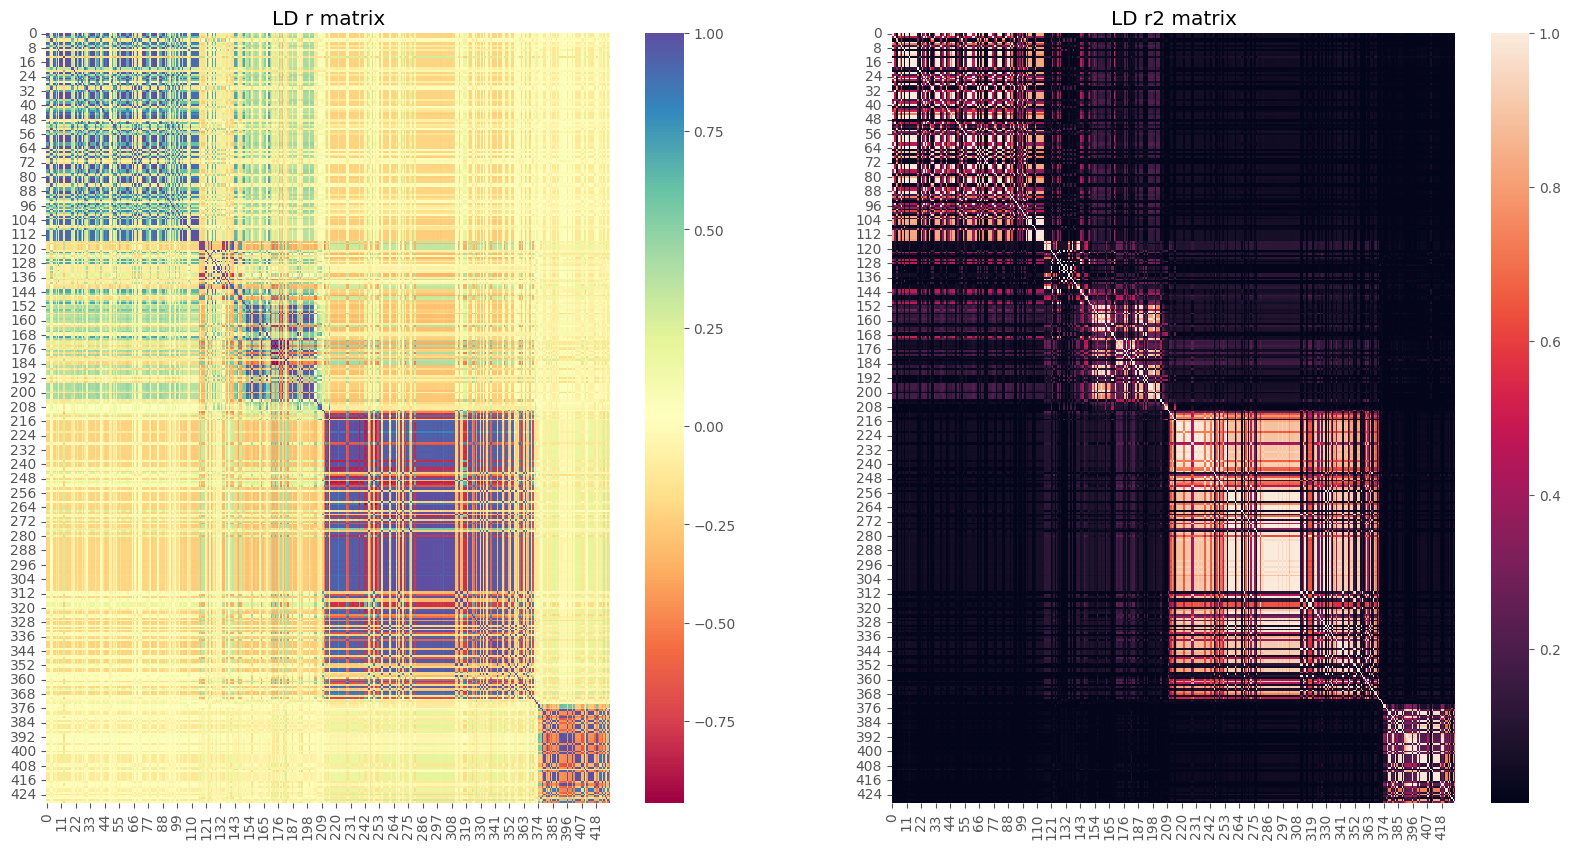

In [193]:
plt.figure(figsize=(10,10),dpi=200)
fig, ax = plt.subplots(ncols=2,figsize=(20,10))
sns.heatmap(data=R_df,cmap="Spectral",ax=ax[0])
sns.heatmap(data=R_df2,ax=ax[1])
ax[0].set_title("LD r matrix")
ax[1].set_title("LD r2 matrix")

In [194]:
ro.r('set.seed(123)')
fit = susieR.susie_rss(
    bhat = df["BETA"].values.reshape(len(R_df), 1),
    shat = df["SE"].values.reshape(len(R_df), 1),
    R = R_df,
    L = 10,
    n = 503
)


 
                  Please check consistency between summary statistics and LD matrix.
                  See https://stephenslab.github.io/susieR/articles/susierss_diagnostic.html

 
                  Please check consistency between summary statistics and LD matrix.
                  See https://stephenslab.github.io/susieR/articles/susierss_diagnostic.html

 
                  Please check consistency between summary statistics and LD matrix.
                  See https://stephenslab.github.io/susieR/articles/susierss_diagnostic.html

 
                  Please check consistency between summary statistics and LD matrix.
                  See https://stephenslab.github.io/susieR/articles/susierss_diagnostic.html

 
                  Please check consistency between summary statistics and LD matrix.
                  See https://stephenslab.github.io/susieR/articles/susierss_diagnostic.html

 
                  Please check consistency between summary statistics and LD matrix.
       

In [195]:
print(susieR.susie_get_cs(fit, coverage = 0.95, min_abs_corr = 0.5, Xcorr = R_df))

$cs
$cs$L1
[1] 319

$cs$L2
[1] 246

$cs$L3
[1] 242

$cs$L4
[1] 243

$cs$L5
[1] 225

$cs$L7
[1] 269

$cs$L8
[1] 263

$cs$L9
[1] 251

$cs$L10
[1] 287 288 289


$purity
    min.abs.corr mean.abs.corr median.abs.corr
L1             1             1               1
L2             1             1               1
L3             1             1               1
L4             1             1               1
L5             1             1               1
L7             1             1               1
L8             1             1               1
L9             1             1               1
L10            1             1               1

$cs_index
[1]  1  2  3  4  5  7  8  9 10

$coverage
[1] 1.0000000 1.0000000 1.0000000 1.0000000 0.9997841 1.0000000 1.0000000
[8] 1.0000000 0.9777084

$requested_coverage
[1] 0.95




In [196]:
df = df.reset_index(drop=True)
df["cs"] = 0
n_cs = len(susieR.susie_get_cs(fit, coverage = 0.95, min_abs_corr = 0.5, Xcorr = R_df)[0])
credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)[0]
for i in range(n_cs):
    cs_index = credible_sets[i]
    df.loc[np.array(cs_index)-1, "cs"] = i + 1

df["pip"] = np.array(susieR.susie_get_pip(fit))
df

,SNPID,CHR,POS,EA,NEA,EAF,BETA,SE,P,STATUS,cs,pip
0,16:53668070:C:CA,16,53668070,CA,C,0.057727,-0.082986,0.023980,5.388460e-04,9999999,0,0.0
1,16:53668214:T:G,16,53668214,G,T,0.057073,-0.085331,0.024041,3.862680e-04,9999999,0,0.0
2,16:53668575:C:G,16,53668575,G,C,0.122528,-0.062887,0.016988,2.140590e-04,9999999,0,0.0
3,16:53668653:C:T,16,53668653,T,C,0.135920,0.105392,0.016279,9.549190e-11,9999999,0,0.0
4,16:53669178:A:T,16,53669178,T,A,0.108305,0.103681,0.017996,8.350220e-09,9999999,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
424,16:53864764:CG:C,16,53864764,C,CG,0.322651,-0.081399,0.012050,1.427590e-11,9999999,0,0.0
425,16:53865226:G:C,16,53865226,C,G,0.263048,-0.099358,0.012676,4.588300e-15,9999999,0,0.0
426,16:53865368:A:AG,16,53865368,AG,A,0.263564,-0.099536,0.012710,4.844240e-15,9999999,0,0.0
427,16:53865701:A:G,16,53865701,G,A,0.323247,-0.081939,0.011985,8.125120e-12,9999999,0,0.0


Create regional plot

0      -3.268535
1      -3.413111
2      -3.669467
3     -10.020033
4      -8.078302
         ...    
424   -10.845397
425   -14.338348
426   -14.314774
427   -11.090170
428   -24.471450
Name: MLOG10P, Length: 429, dtype: float64


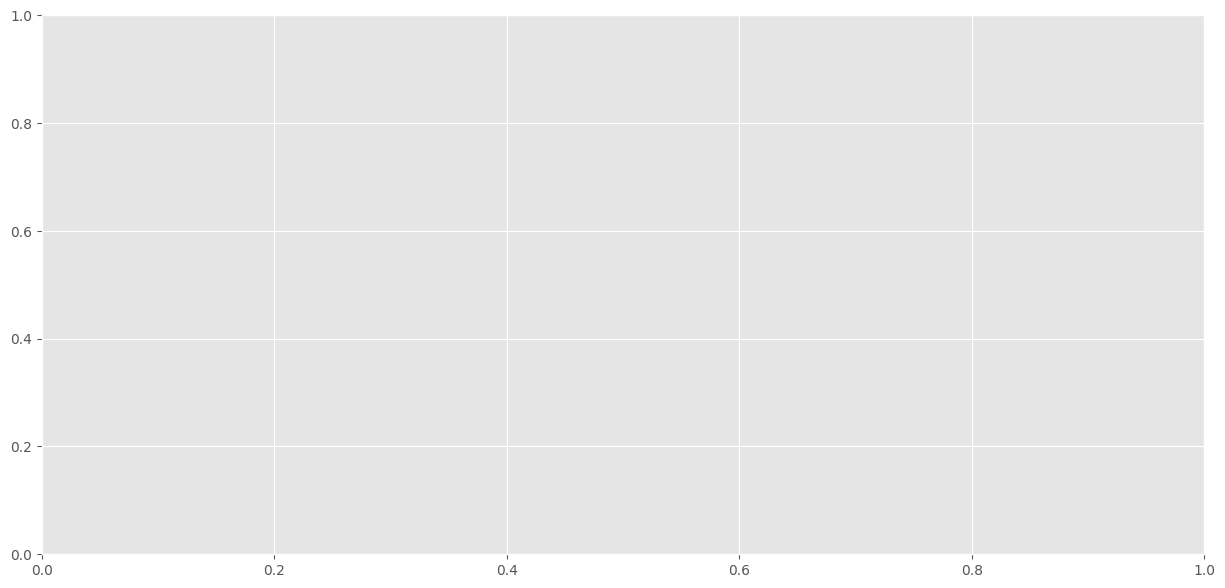

In [ ]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))
col_to_plot = "MLOG10P"
df[col_to_plot] = -np.log10(df["P"])
print(df[col_to_plot])

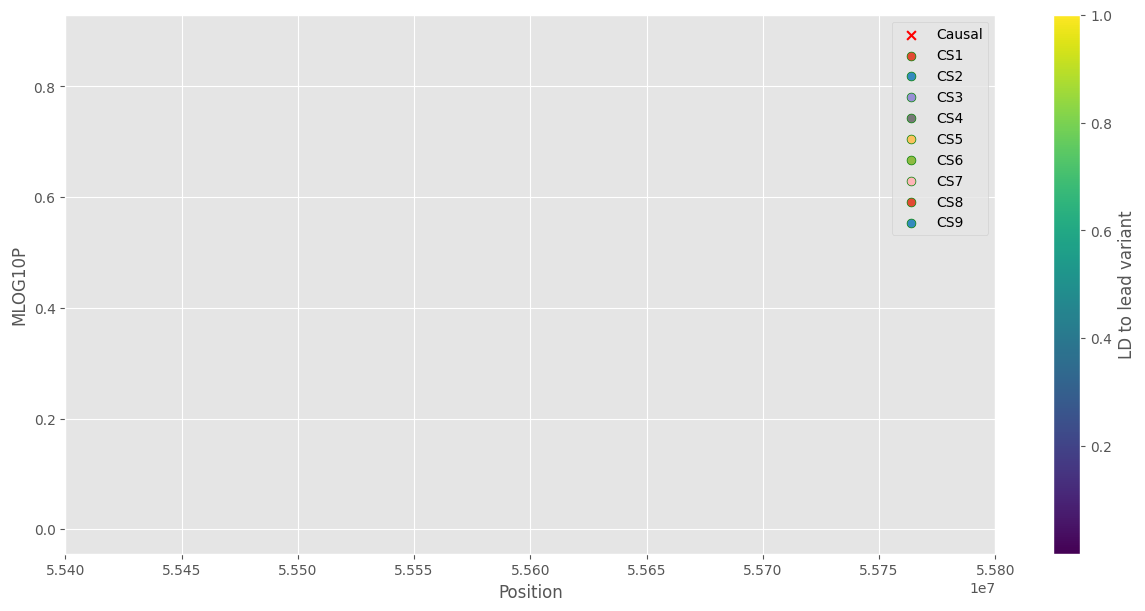

In [ ]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))
col_to_plot = "MLOG10P"
df[col_to_plot] = -np.log10(df["P"])
print(df[col_to_plot])
#plot the variants with their LD score to the lead variant
p=ax.scatter(df["POS"], df[col_to_plot], c=ld2[df["P"].idxmin()])
#show the lead variant
lead_x, lead_y = df.loc[df["P"].idxmin(), "POS"], df.loc[df["P"].idxmin(), col_to_plot]
ax.annotate(f"Lead Variant: {df.loc[df['P'].idxmin(), 'SNPID']}", 
            (lead_x, lead_y), 
            textcoords="offset points", xytext=(0, lead_y + 2), ha='center', fontsize=12)

#plot the causal variant
ax.scatter(df.loc[(df["CHR"]==2)&(df["POS"]==55620927),"POS"],df.loc[(df["CHR"]==2)&(df["POS"]==55620927),col_to_plot],
           marker='x',s=40,c="red",label="Causal")

#plot circles around variants in credible sets
for i in range(n_cs):
    cs_index = credible_sets[i]
    pos = df.loc[np.array(cs_index)-1, "POS"]
    y = df.loc[np.array(cs_index)-1, col_to_plot]
    ax.scatter(pos, y, marker='o', s=40, label=f"CS{i+1}", edgecolor="green")



plt.colorbar(p, label="LD to lead variant")
ax.set_xlabel("Position")
ax.set_ylabel(col_to_plot)
ax.set_xlim((55400000, 55800000))
plt.legend()
plt.show()

In [22]:

from rpy2.robjects.packages import importr
import rpy2.robjects as ro
import rpy2.robjects.numpy2ri as numpy2ri
import rpy2.robjects.pandas2ri as pandas2ri
numpy2ri.activate()
pandas2ri.activate()

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /usr/lib/R
INFO:rpy2.situation:R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/home/icog-bioai/jdk-11.0.2/lib/server
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/home/icog-bioai/jdk-11.0.2/lib/server
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.


In [179]:
susieR = importr('susieR')

In [181]:
#Load LD data
ld = pd.read_csv("../data/ld/plot_sig_locus_mt.ld", sep="\t", header=None)
R_df = ld.values
ld2 = pd.read_csv("../data/ld/plot_sig_locus_mt_r2.ld",sep="\t",header=None)
R_df2 = ld2.values
R_df.shape

(429, 429)

In [140]:
ld2.shape

(429, 429)

Text(0.5, 1.0, 'LD r2 matrix')

<Figure size 2000x2000 with 0 Axes>

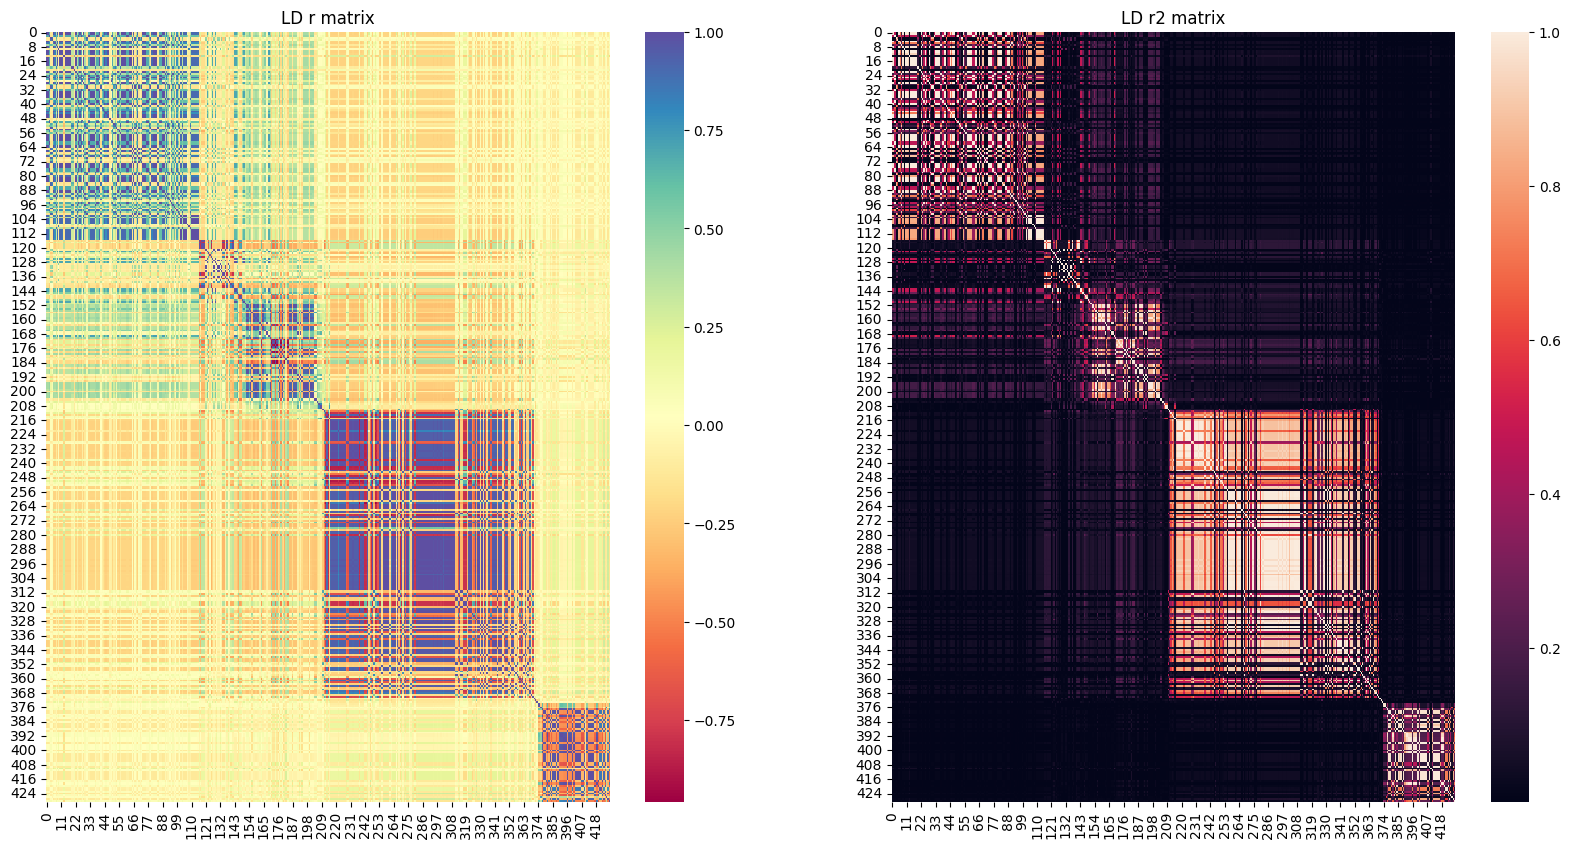

In [27]:
plt.figure(figsize=(10,10),dpi=200)
fig, ax = plt.subplots(ncols=2,figsize=(20,10))
sns.heatmap(data=R_df,cmap="Spectral",ax=ax[0])
sns.heatmap(data=R_df2,ax=ax[1])
ax[0].set_title("LD r matrix")
ax[1].set_title("LD r2 matrix")

In [43]:
df["SE"].head()

11445981    0.023980
11445982    0.024041
11445983    0.016988
11445984    0.016279
11445985    0.017996
Name: SE, dtype: float64

In [182]:
print(df["BETA"].shape)  # Should match len(R_df)
print(df["SE"].shape)    # Should match len(R_df)
print(R_df.shape)        # Should be (N, N) where N = len(df["BETA"])


(433,)
(433,)
(429, 429)


In [137]:
num_snps = R_df.shape[0]  # 429

fit = susieR.susie_rss(
    bhat=df["BETA"].values[:num_snps].reshape(num_snps, 1),
    shat=df["SE"].values[:num_snps].reshape(num_snps, 1),
    R=R_df,
    L=10,
    n=503
)


429


In [ ]:
print(susieR.susie_get_cs(fit, coverage = 0.95, min_abs_corr = 0.5, Xcorr = R_df))

$cs
$cs$L1
[1] 319

$cs$L2
[1] 246

$cs$L3
[1] 242

$cs$L4
[1] 243

$cs$L5
[1] 225

$cs$L7
[1] 269

$cs$L8
[1] 263

$cs$L9
[1] 251

$cs$L10
[1] 287 288 289


$purity
    min.abs.corr mean.abs.corr median.abs.corr
L1             1             1               1
L2             1             1               1
L3             1             1               1
L4             1             1               1
L5             1             1               1
L7             1             1               1
L8             1             1               1
L9             1             1               1
L10            1             1               1

$cs_index
[1]  1  2  3  4  5  7  8  9 10

$coverage
[1] 1.0000000 1.0000000 1.0000000 1.0000000 0.9997841 1.0000000 1.0000000
[8] 1.0000000 0.9777084

$requested_coverage
[1] 0.95




we have 9 crediable sets(n_cs)


In [145]:
df["cs"] = 0
df = df.head(429)
df = df.head(429).reset_index(drop=True)

n_cs = len(susieR.susie_get_cs(fit, coverage = 0.95, min_abs_corr = 0.5, Xcorr = R_df)[0])
credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)[0]
for i in range(n_cs):
    df = df.reset_index(drop=True)
    cs_index = credible_sets[i]
    df.loc[np.array(cs_index)-1, "cs"] = i + 1

df["pip"] = np.array(susieR.susie_get_pip(fit))
df


# pip_values = np.array(susieR.susie_get_pip(fit))
# # pip_values_shape=pip_values[:len(df)]
# # pip_values_shape




,SNPID,CHR,POS,EA,NEA,EAF,BETA,SE,P,STATUS,MLOG10P
0,16:53668070:C:CA,16,53668070,CA,C,0.057727,-0.082986,0.023980,5.388460e-04,9999999,3.268535
1,16:53668214:T:G,16,53668214,G,T,0.057073,-0.085331,0.024041,3.862680e-04,9999999,3.413111
2,16:53668575:C:G,16,53668575,G,C,0.122528,-0.062887,0.016988,2.140590e-04,9999999,3.669467
3,16:53668653:C:T,16,53668653,T,C,0.135920,0.105392,0.016279,9.549190e-11,9999999,10.020033
4,16:53669178:A:T,16,53669178,T,A,0.108305,0.103681,0.017996,8.350220e-09,9999999,8.078302


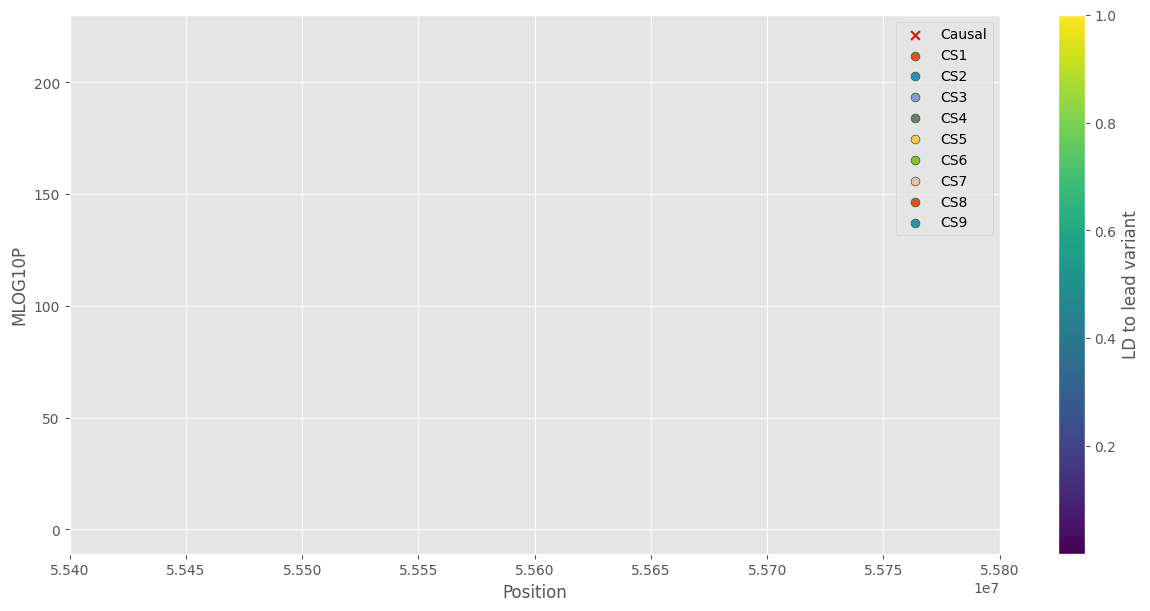

In [155]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))
col_to_plot = "MLOG10P"
df[col_to_plot] = -np.log10(df["P"])
#plot the variants with their LD score to the lead variant
p=ax.scatter(df["POS"], df[col_to_plot], c=ld2[df["P"].idxmin()])
#show the lead variant
lead_x, lead_y = df.loc[df["P"].idxmin(), "POS"], df.loc[df["P"].idxmin(), col_to_plot]
ax.annotate(f"Lead Variant: {df.loc[df['P'].idxmin(), 'SNPID']}", 
            (lead_x, lead_y), 
            textcoords="offset points", xytext=(0, lead_y + 2), ha='center', fontsize=12)

#plot the causal variant
ax.scatter(df.loc[(df["CHR"]==2)&(df["POS"]==55620927),"POS"],df.loc[(df["CHR"]==2)&(df["POS"]==55620927),col_to_plot],
           marker='x',s=40,c="red",label="Causal")

#plot circles around variants in credible sets
for i in range(n_cs):
    cs_index = credible_sets[i]
    pos = df.loc[np.array(cs_index)-1, "POS"]
    y = df.loc[np.array(cs_index)-1, col_to_plot]
    ax.scatter(pos, y, marker='o', s=40, label=f"CS{i+1}", edgecolor="green")



plt.colorbar(p, label="LD to lead variant")
ax.set_xlabel("Position")
ax.set_ylabel(col_to_plot)
ax.set_xlim((55400000, 55800000))
plt.legend()
plt.show()

In [131]:
df["P"]= pip_values

ValueError: Length of values (429) does not match length of index (433)

KeyError: 11446510

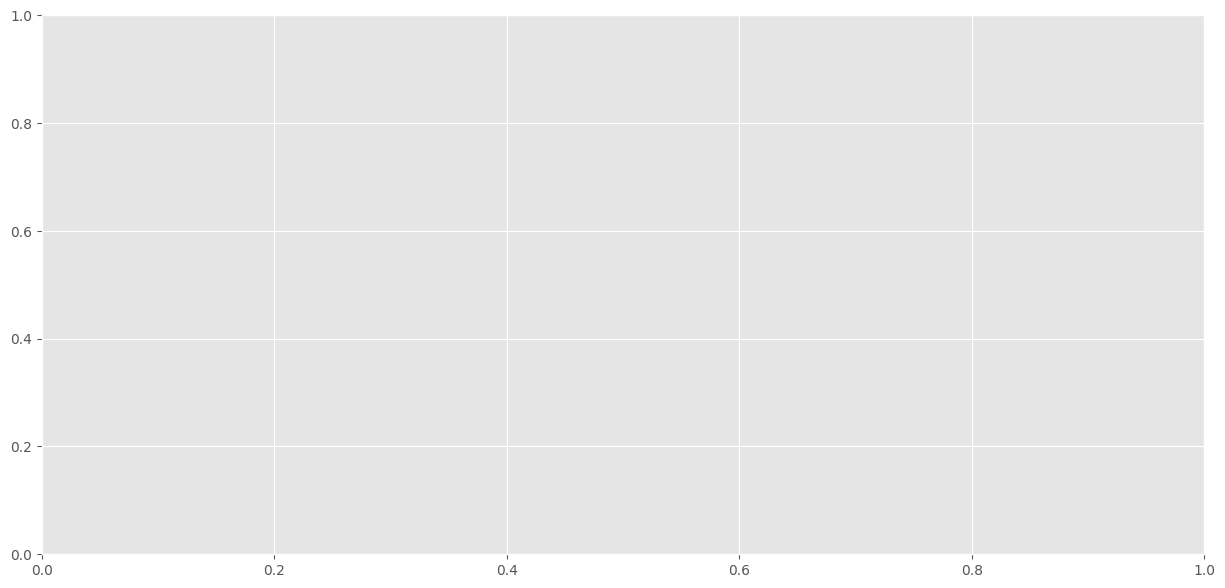

In [52]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))
col_to_plot = "MLOG10P"
df[col_to_plot] = -np.log10(df["P"])
#plot the variants with their LD score to the lead variant
p=ax.scatter(df["POS"], df[col_to_plot], c=ld2[df["P"].idxmin()])
#show the lead variant
lead_x, lead_y = df.loc[df["P"].idxmin(), "POS"], df.loc[df["P"].idxmin(), col_to_plot]
ax.annotate(f"Lead Variant: {df.loc[df['P'].idxmin(), 'SNPID']}", 
            (lead_x, lead_y), 
            textcoords="offset points", xytext=(0, lead_y + 2), ha='center', fontsize=12)

#plot the causal variant
ax.scatter(df.loc[(df["CHR"]==2)&(df["POS"]==55620927),"POS"],df.loc[(df["CHR"]==2)&(df["POS"]==55620927),col_to_plot],
           marker='x',s=40,c="red",label="Causal")

#plot circles around variants in credible sets
for i in range(n_cs):
    cs_index = credible_sets[i]
    pos = df.loc[np.array(cs_index)-1, "POS"]
    y = df.loc[np.array(cs_index)-1, col_to_plot]
    ax.scatter(pos, y, marker='o', s=40, label=f"CS{i+1}", edgecolor="green")



plt.colorbar(p, label="LD to lead variant")
ax.set_xlabel("Position")
ax.set_ylabel(col_to_plot)
ax.set_xlim((55400000, 55800000))
plt.legend()
plt.show()

In [ ]:
wget ftp://ftp.ncbi.nih.gov/snp/latest_release/VCF/GCF_000001405.25.gz -O dbsnp_151_GRCh37.vcf.gz



bcftools index ALL.chr16.vcf.gz

bcftools annotate -a dbsnp_151_GRCh37.vcf.gz -c ID -O z -o annotated_chr16.vcf.gz ALL.chr16.vcf.gz


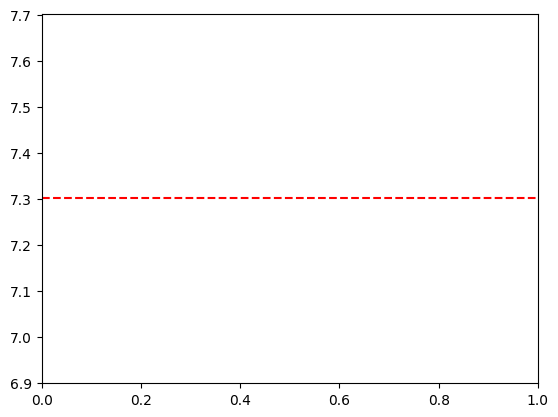

In [21]:
plt.axhline(y=-np.log10(5e-8), color='red', linestyle='--')
plt.show()

In [22]:
minor_df.plt(skip=2,anno=True)

AttributeError: 'DataFrame' object has no attribute 'plt'

In [95]:
sumstatus.plot_mqq(mode="r", anno=True, region=(2,54513738,56513738), region_grid=True, build='hg19')

UnboundLocalError: local variable 'snpid' referenced before assignment

In [10]:
# gl.download_ref("1kg_eas_hg19")

2025/01/21 22:15:42 Start to download  1kg_eas_hg19  ...
2025/01/21 22:15:42  -Downloading to: /home/icog-bioai/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz
2025/01/21 22:15:42  -File /home/icog-bioai/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz exists.
2025/01/21 22:15:49  -File path: /home/icog-bioai/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz
2025/01/21 22:15:49  -MD5 check: c8c97434843c0da3113fc06879ead472
2025/01/21 22:15:49  -MD5 verified.
2025/01/21 22:15:49  -Updating record in config file...
2025/01/21 22:15:49  -File /home/icog-bioai/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz.tbi exists.
2025/01/21 22:15:49  -Updating record in config file...
2025/01/21 22:15:49  -Downloading to: /home/icog-bioai/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz.tbi
2025/01/21 22:15:49 Downloaded  1kg_eas_hg19  successfully!


2025/01/21 22:15:58 Start to create MQQ plot...v3.5.5:
2025/01/21 22:15:58  -Genomic coordinates version: 19...
2025/01/21 22:15:58  -Genome-wide significance level to plot is set to 5e-08 ...
2025/01/21 22:15:58  -Raw input contains 907921 variants...
2025/01/21 22:15:58  -MQQ plot layout mode is : r
2025/01/21 22:15:58  -Region to plot : chr2:54531536-56731536.
2025/01/21 22:15:58  -Checking chromosome notations in VCF/BCF files...
2025/01/21 22:15:58  -Checking prefix for chromosomes in VCF/BCF files...
2025/01/21 22:15:58  -No prefix for chromosomes in the VCF/BCF files.
2025/01/21 22:15:58  -Extract SNPs in region : chr2:54531536-56731536...
2025/01/21 22:15:58  -Extract SNPs in specified regions: 795
2025/01/21 22:15:58 Finished loading specified columns from the sumstats.
2025/01/21 22:15:58 Start data conversion and sanity check:
2025/01/21 22:15:58  -Removed 0 variants with nan in CHR or POS column ...
2025/01/21 22:15:58  -Removed 0 variants with CHR <=0...
2025/01/21 22:15:5

2025/01/21 22:26:43  -Retrieving index...
2025/01/21 22:26:43  -Ref variants in the region: 71908
2025/01/21 22:26:43  -Matching variants using POS, NEA, EA ...
2025/01/21 22:26:43  -Calculating Rsq...
2025/01/21 22:26:43 Finished loading reference genotype successfully!
2025/01/21 22:26:43  -Creating background plot...
2025/01/21 22:26:43  -Extracting lead variant...
2025/01/21 22:26:44  -Loading gtf files from:default


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_name', 'gene_biotype']


2025/01/21 22:27:21  -plotting gene track..
2025/01/21 22:27:21  -plotting genes: 14..
2025/01/21 22:27:21  -plotting exons: 1044..
2025/01/21 22:27:21  -Finished plotting gene track..


2025/01/21 22:27:22 Finished creating MQQ plot successfully!
2025/01/21 22:27:22 Start to extract variants for annotation...
2025/01/21 22:27:22  -Found 1 significant variants with a sliding window size of 500 kb...
2025/01/21 22:27:22 Finished extracting variants for annotation...
2025/01/21 22:27:22 Start to process figure arts.
2025/01/21 22:27:22  -Processing X labels...
2025/01/21 22:27:22  -Processing Y labels...
2025/01/21 22:27:22  -Processing Y tick lables...
2025/01/21 22:27:22  -Processing Y labels...
2025/01/21 22:27:22  -Processing color bar...
2025/01/21 22:27:22  -Processing lines...
2025/01/21 22:27:22 Finished processing figure arts.
2025/01/21 22:27:22 Start to annotate variants...
2025/01/21 22:27:22  -Annotating using column CHR:POS...
2025/01/21 22:27:22  -Adjusting text positions with repel_force=0.03...
2025/01/21 22:27:22 Finished annotating variants.
2025/01/21 22:27:22 Start to save figure...
2025/01/21 22:27:22  -Skip saving figure!
2025/01/21 22:27:22 Finish

(<Figure size 3000x2000 with 4 Axes>, <gwaslab.g_Log.Log at 0x7244ee19fa30>)

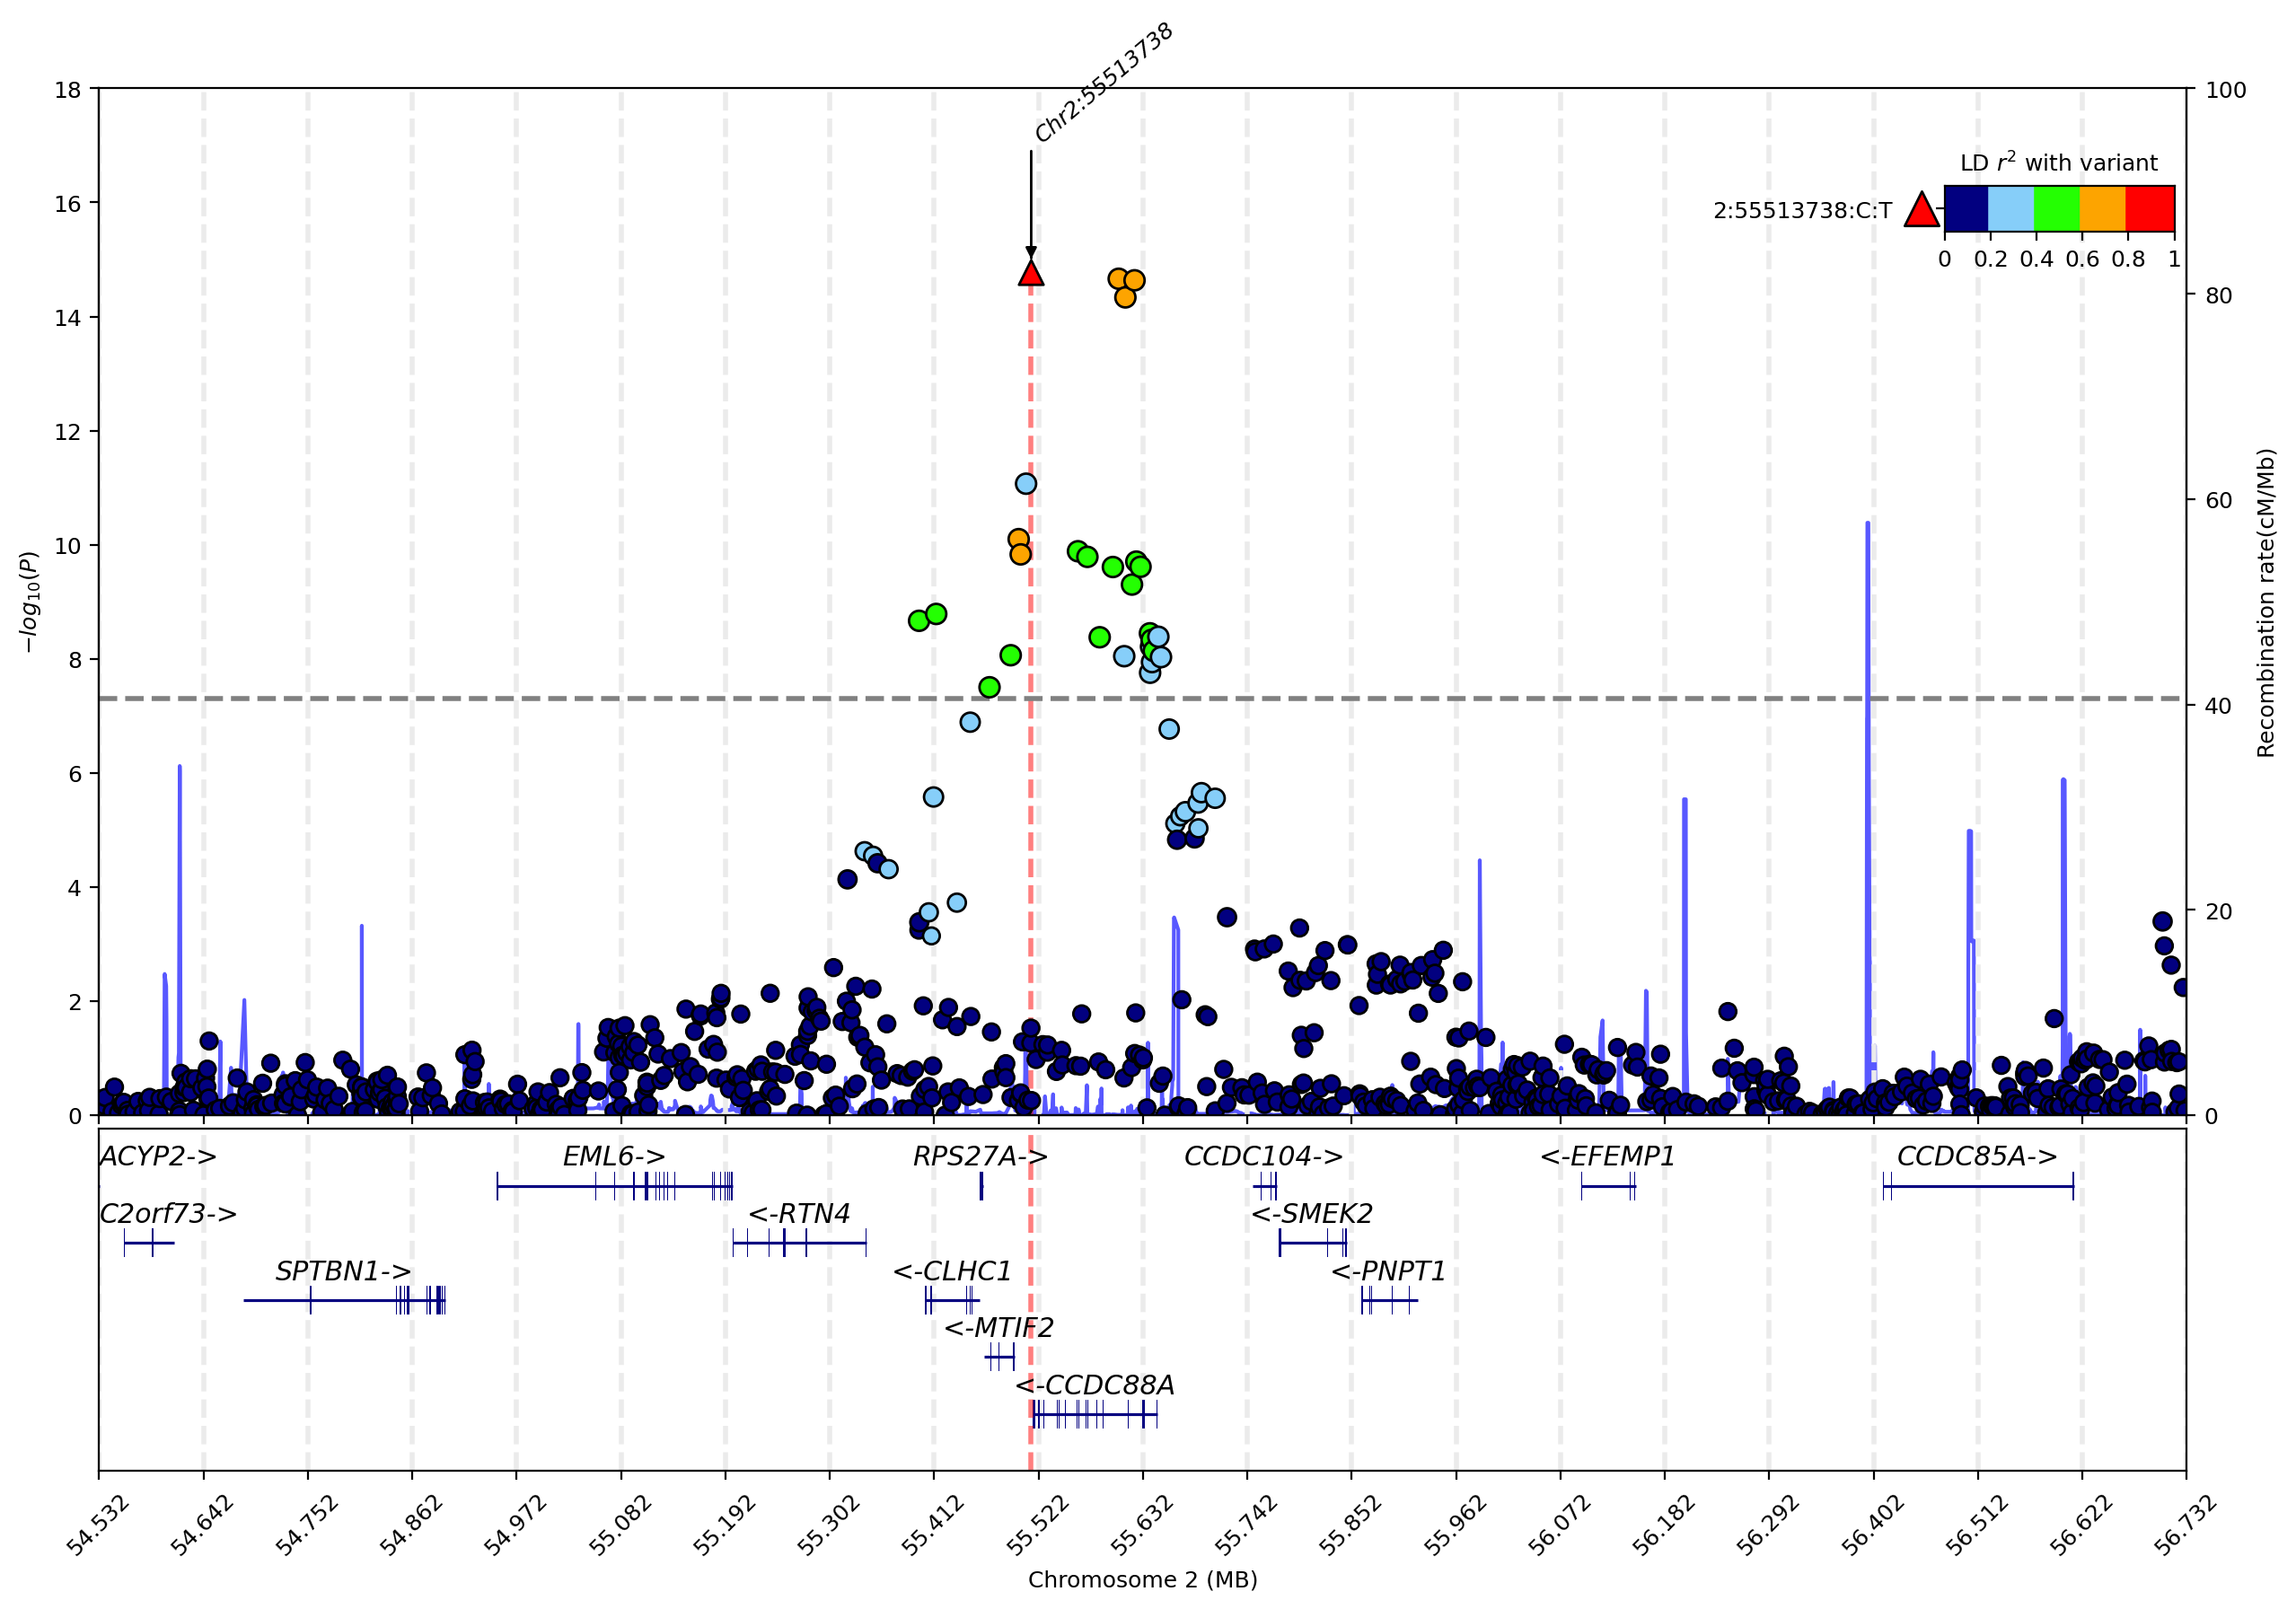

In [11]:
# sumstatus.plot_mqq(mode="r",anno=True,region=(2,54531536,56731536),region_grid=True,vcf_path=gl.get_path("1kg_eas_hg19"),build="19")